# Rhabdoid cohorts clinical plots

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## SJD data

In [2]:
sjd_df = pd.read_csv('clinical_data/SJD_clinical_data_patient.tsv',sep='\t')
sjd_df = sjd_df[0:20]
exclude_pts = ['2','10','16','20']
sjd_df = sjd_df[~sjd_df['PATIENT_ID'].isin(exclude_pts)]
print(len(sjd_df))
sjd_df

16


,PATIENT_ID,GENDER,TUMOR_TYPE,TAB_DIAGNOSIS,TREATMENT,TAB_TTMT_START_DATE,TAB_TTMT_END_DATE,STATUS (Deceased/Alive),SAMPLE_AVAILABILITY,Diagnosis,Primary tumor,Metastasis (at debut),Site of relapse,Unnamed: 13
0,1,Male,MRT,8.29,mP6 protocol + surgery + radiotherapy,8.32,8.67,Alive,Diagnosis. Second look surgery (post-chemo),MRT,Pelvis,No,NaN,NaN
2,3,Male,MRT,4.75,St Jude protocol (incomplete) + surgery + radi...,4.79,5.05,Deceased,"Diagnosis, Relapse post chemo (Lung)",RTK,Kidney,No,"lung, lymph nodes",NaN
3,4,Female,MRT,0.02,No treatment,NaN,NaN,Deceased,"Diagnosis, Necropsy (no treatment)",MRT,Skin and soft tissue,lymph nodes,NaN,NaN
4,5,Male,MRT,13.50,St Jude protocol (incomplete),13.58,13.63,Deceased,"Diagnosis, Diagnosis, Necropsy (post chemo)",MRT,Paraspinal,"lymph nodes, lung",PD,NaN
5,6,Male,ATRT,1.52,Boston protocol,1.56,NaN,Deceased,"Post chemo, Necropsy (post chemo)",MRT,CNS (cervical),lung,PD,NaN
6,7,Male,ATRT,1.98,surgery + COG,1.98,2.19,Alive,Recurrence (post chemo),ATRT,Brain,No,PD,NaN
7,8,Male,ATRT,3.00,surgery + Dana Farber + radiotherapy,3.06,3.4,Alive,Diagnosis,ATRT,Brain,No,NaN,NaN
8,9,Female,MRT,0.48,mP6 protocol + surgery,0.45,0.52,Deceased,"Diagnosis, Second look surgery (post chemo)",MRT,Liver,No,PD,NaN
10,11,Female,ATRT,5.57,Dana Farber + surgery + radiotherapy + retinoi...,5.56,9.2,Deceased,Diagnosis,ATRT,Brain,CSF,NaN,NaN
11,12,Male,MRT,0.62,mP6 + surgery + radiotherapy + tamoxifen + ret...,0.17,NaN,Deceased,"Progression (post chemo), Progression (post ch...",MRT,Armpit,lung,"PD (LUNG, LIVER, KIDNEYS)",NaN


## TARGET data

In [3]:
empty_cell = "'--"
empty_col = [empty_cell] * 69

In [5]:
target_df = pd.read_csv('clinical_data/TARGET_clinical_data.tsv',sep='\t')
cols = list(target_df)
info_cols = []
for col in cols:
    column = target_df[col].tolist()
    if column != empty_col:
        info_cols.append(col)
target_df = target_df[info_cols]
target_df

,case_id,case_submitter_id,project_id,days_to_death,ethnicity,gender,race,vital_status,age_at_diagnosis,cog_renal_stage,days_to_last_follow_up,last_known_disease_status,morphology,primary_diagnosis,progression_or_recurrence,site_of_resection_or_biopsy,tissue_or_organ_of_origin,tumor_grade,year_of_diagnosis
0,01444de8-344b-566e-a461-8ef82b0796d8,TARGET-52-PAKPEW,TARGET-RT,153,not hispanic or latino,male,white,Dead,950,Stage IV,153.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2001
1,0f9e1dc9-5003-5628-8c3f-5e599a13c90d,TARGET-52-PAUEKW,TARGET-RT,'--,not hispanic or latino,female,other,Alive,5386,Stage III,625.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2011
2,105d2431-78e7-5e34-b620-0b9d4fd9d1a3,TARGET-52-PASGGN,TARGET-RT,112,not hispanic or latino,male,white,Dead,130,Stage IV,112.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2008
3,122eba47-a308-5c80-a332-06b37f12cc3a,TARGET-52-PAJLRA,TARGET-RT,16,Unknown,female,white,Dead,3,Stage III,16.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,1996
4,153c5c30-41d5-5369-873f-d086ead699a4,TARGET-52-PASVDP,TARGET-RT,'--,not hispanic or latino,female,white,Alive,141,Stage III,1.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,External upper lip,External upper lip,Not Reported,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,ea300498-806d-56cf-9cca-adb64f869e7b,TARGET-52-PARUGK,TARGET-RT,'--,hispanic or latino,male,white,Alive,220,Stage III,1.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2008
65,ead9a4f1-e7d2-5341-93a0-a67267c28728,TARGET-52-PASAMZ,TARGET-RT,'--,hispanic or latino,female,white,Alive,3027,Stage I,1746.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,External upper lip,External upper lip,Not Reported,2008
66,ee33dcef-f61c-5ee0-9c65-a4eb475a2406,TARGET-52-PAVDPR,TARGET-RT,'--,not hispanic or latino,male,white,Unknown,749,Stage IV,'--,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,2012
67,ef42d20f-5f3e-58c6-9d52-0a2aa48a162c,TARGET-52-PAJNFZ,TARGET-RT,48,Unknown,male,black or african american,Dead,592,Stage IV,48.0,not reported,8963/3,Malignant rhabdoid tumor,not reported,"Kidney, NOS","Kidney, NOS",Not Reported,1999


In [6]:
# get patients with bam
target_samples_list = []
for n in range(1,8):
    df1 = pd.read_csv('variant_calling/target_cohort/sarek_results/input_fastq_batch'+str(n)+'.csv')
    p = list(df1['patient'].unique())
    target_samples_list = target_samples_list + p
print(len(target_samples_list))

target_df['PATIENT'] = target_df['case_submitter_id'].str.split('-',expand=True)[2]
target_df['AGE_DIAGNOSIS'] = target_df['age_at_diagnosis'] / 365
target_df = target_df[target_df['PATIENT'].isin(target_samples_list)]

target_df[['PATIENT','AGE_DIAGNOSIS']]

56


,PATIENT,AGE_DIAGNOSIS
1,PAUEKW,14.756164
4,PASVDP,0.386301
5,PAREWI,0.841096
6,PAUNPA,2.843836
7,PATXKA,0.279452
8,PAJLWM,0.794521
9,PATDVL,0.400000
11,PAVYDM,0.463014
12,PABKLN,1.095890
13,PAJMRB,1.482192


## ST JUDE data

In [8]:
import json

In [9]:
stjude_dict = json.load(open('sample_ids/sample_stjude_ids.json','rb'))
stjude_tumors = [stjude_dict[pt]['tumor1'] for pt in stjude_dict.keys()]
bad_quality_samples = ['SJBT032047_D1','SJBT033133_D3']
xenograft = ['SJMRT063832_X1']
no_age_data = ['SJMRT014754_D1']
exclude_samples =  bad_quality_samples + xenograft+ no_age_data
stjude_tumors = [t for t in stjude_tumors if t not in exclude_samples]
print(len(stjude_tumors))
stjude_tumors

16


['SJMRT015723_D1',
 'SJBT030128_D1',
 'SJBT030255_D1',
 'SJBT030581_D1',
 'SJBT030707_D2',
 'SJBT030896_D1',
 'SJBT030997_D1',
 'SJBT031235_D1',
 'SJBT031605_D1',
 'SJBT031948_D2',
 'SJBT032346_D1',
 'SJBT032393_D1',
 'SJBT032417_D2',
 'SJBT033236_D2',
 'SJBT034089_D1',
 'SJBT034110_D2']

In [10]:
stjude_df = pd.read_csv('clinical_data/StJude_clinical_data.txt',sep='\t')
df1 = pd.read_csv('variant_calling/stjude_cohort/sarek_results/input_fastq.csv')
pts = df1['patient'].unique()
stjude_df = stjude_df[stjude_df['subject_name'].isin(pts)]
stjude_df = stjude_df[stjude_df['sample_name'].isin(stjude_tumors)]
stjude_df = stjude_df[stjude_df['sample_type'].isin(['Diagnosis','Other','Metastasis'])]
stjude_df = stjude_df[stjude_df['file_path'].str.endswith('bam')]
stjude_df = stjude_df[['subject_name','sample_name','sj_long_disease_name',
       'attr_age_at_diagnosis', 'attr_diagnosis', 'attr_sex', 'attr_ethnicity',
       'attr_race','attr_subtype_biomarkers',
       'sj_associated_diagnoses',
       'attr_diagnosis_group', 'sj_access_unit',
       'sj_diseases', 'sj_datasets',
       'sj_disease_hierarchy_code', 'sj_disease_hierarchy_name'       ]]
stjude_df

,subject_name,sample_name,sj_long_disease_name,attr_age_at_diagnosis,attr_diagnosis,attr_sex,attr_ethnicity,attr_race,attr_subtype_biomarkers,sj_associated_diagnoses,attr_diagnosis_group,sj_access_unit,sj_diseases,sj_datasets,sj_disease_hierarchy_code,sj_disease_hierarchy_name
3,SJ030255,SJBT030255_D1,Atypical Teratoid/Rhabdoid Tumors,2.42,Atypical Teratoid Rhabdoid Tumor,Male,Not Hispanic Or Latino,Asian,Not Available,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Genomes 4 Kids (G4K),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
4,SJ030128,SJBT030128_D1,Atypical Teratoid/Rhabdoid Tumors,1.17,Atypical Teratoid Rhabdoid Tumor,Female,Not Hispanic Or Latino,White,Not Available,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Genomes 4 Kids (G4K),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
12,SJ030581,SJBT030581_D1,Atypical Teratoid/Rhabdoid Tumors,10.25,"ATYPICAL TERATOID RHABDOID TUMOR, TEMPORAL LOB...",Male,Not Hispanic Or Latino,Black Or African American,NaN,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
14,SJ030997,SJBT030997_D1,Atypical Teratoid/Rhabdoid Tumors,0.50,"ATYPICAL TERATOID RHABDOID TUMOR, TEMPORAL LOB...",Female,Hispanic Or Latino,White,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
35,SJ030896,SJBT030896_D1,Atypical Teratoid/Rhabdoid Tumors,2.75,"ATYPICAL TERATOID RHABDOID TUMOR, LEFT FRONTAL...",Male,Not Hispanic Or Latino,Other,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
41,SJ030707,SJBT030707_D2,Atypical Teratoid/Rhabdoid Tumors,1.58,"ATYPICAL TERATOID RHABDOID TUMOR, POSTERIOR FOSSA",Male,Not Hispanic Or Latino,Black Or African American,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
45,SJ031235,SJBT031235_D1,Atypical Teratoid/Rhabdoid Tumors,0.67,"ATYPICAL TERATOID/RHABDOID TUMOR, FORTH VENTRICLE",Female,Not Hispanic Or Latino,White,SMARCB1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
46,SJ015723,SJMRT015723_D1,"Rhabdoid Cancer, Kidney",1.00,Not Available,Male,Not Available,Not Available,Not Available,"Rhabdoid Cancer, Kidney (MRT)",Solid Tumor,PCGP,MRT,Childhood Solid Tumor Network (CSTN),ST|KID|MRT,"Solid Tumor|Kidney|Rhabdoid Cancer, Kidney"
65,SJ031605,SJBT031605_D1,Atypical Teratoid/Rhabdoid Tumors,2.25,"ATYPICAL TERATOID RHABDOID TUMOR, FRONTOTEMPOR...",Male,Not Hispanic Or Latino,Declined To Respond,NF1,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...
75,SJ032393,SJBT032393_D1,Atypical Teratoid/Rhabdoid Tumors,14.00,Malignant neoplasm of overlapping sites of brain,Female,Not Hispanic Or Latino,White,SMARCB1 LOSS,Atypical Teratoid/Rhabdoid Tumors (ATRT),Brain Tumor,ClinicalGenomics,ATRT,Real-time Clinical Genomics (RTCG),BT|EMBT|EMBCNST|ATRT,Brain Tumor|Embryonal Tumors|Other CNS Embryon...


## CONCAT tables

In [11]:
cols = ['PATIENT','AGE_DIAGNOSIS','SEX','TUMOR_TYPE','PRY_TUMOR_SITE','COHORT']

In [12]:
sjd_df['PATIENT'] = sjd_df['PATIENT_ID'].replace('14*','14')
sjd_df['TUMOR_TYPE'] = sjd_df['TUMOR_TYPE'].replace('SMARCA4mut','ATRT')
sjd_df['PRY_TUMOR_SITE'] = sjd_df['Primary tumor'].replace('Skin and soft tissue','Soft tissue').replace('CNS (cervical)','Brain').replace('Laterocervical soft tissue','Soft tissue').replace('Soft tissue (multiple tumor masses)','Soft tissue')
sjd_df['SEX'] = sjd_df['GENDER']
sjd_df['AGE_DIAGNOSIS'] = sjd_df['TAB_DIAGNOSIS']
sjd_df['COHORT'] = 'SJD'
sjd_df[cols]

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
0,1,8.29,Male,MRT,Pelvis,SJD
2,3,4.75,Male,MRT,Kidney,SJD
3,4,0.02,Female,MRT,Soft tissue,SJD
4,5,13.50,Male,MRT,Paraspinal,SJD
5,6,1.52,Male,ATRT,Brain,SJD
6,7,1.98,Male,ATRT,Brain,SJD
7,8,3.00,Male,ATRT,Brain,SJD
8,9,0.48,Female,MRT,Liver,SJD
10,11,5.57,Female,ATRT,Brain,SJD
11,12,0.62,Male,MRT,Armpit,SJD


In [13]:
target_df['SEX'] = target_df['gender'].replace('female','Female')
target_df['SEX'] = target_df['SEX'].replace('male','Male')
target_df['TUMOR_TYPE'] = target_df['primary_diagnosis'].replace('Malignant rhabdoid tumor','MRT')
target_df['PRY_TUMOR_SITE'] = target_df['site_of_resection_or_biopsy'].replace('Kidney, NOS','Kidney')
target_df['COHORT'] = 'TARGET'
target_df[cols]

/tmp/ipykernel_26032/16774340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df['SEX'] = target_df['gender'].replace('female','Female')
/tmp/ipykernel_26032/16774340.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df['SEX'] = target_df['SEX'].replace('male','Male')
/tmp/ipykernel_26032/16774340.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
1,PAUEKW,14.756164,Female,MRT,Kidney,TARGET
4,PASVDP,0.386301,Female,MRT,External upper lip,TARGET
5,PAREWI,0.841096,Female,MRT,Kidney,TARGET
6,PAUNPA,2.843836,Male,MRT,Kidney,TARGET
7,PATXKA,0.279452,Female,MRT,Liver,TARGET
8,PAJLWM,0.794521,Male,MRT,Kidney,TARGET
9,PATDVL,0.400000,Male,MRT,Kidney,TARGET
11,PAVYDM,0.463014,Female,MRT,Kidney,TARGET
12,PABKLN,1.095890,Male,MRT,Kidney,TARGET
13,PAJMRB,1.482192,Female,MRT,Kidney,TARGET


In [14]:
stjude_df['PATIENT'] = stjude_df['subject_name']
stjude_df['AGE_DIAGNOSIS'] = stjude_df['attr_age_at_diagnosis']
stjude_df['SEX'] = stjude_df['attr_sex']
stjude_df['TUMOR_TYPE'] = stjude_df['sj_associated_diagnoses'].str.split('(',expand=True)[1].str.split(')',expand=True)[0]
stjude_df['PRY_TUMOR_SITE'] = stjude_df['TUMOR_TYPE'].replace('ATRT','Brain').replace('MRT','Kidney')
stjude_df['COHORT'] = 'StJude'
stjude_df[cols]

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
3,SJ030255,2.42,Male,ATRT,Brain,StJude
4,SJ030128,1.17,Female,ATRT,Brain,StJude
12,SJ030581,10.25,Male,ATRT,Brain,StJude
14,SJ030997,0.50,Female,ATRT,Brain,StJude
35,SJ030896,2.75,Male,ATRT,Brain,StJude
41,SJ030707,1.58,Male,ATRT,Brain,StJude
45,SJ031235,0.67,Female,ATRT,Brain,StJude
46,SJ015723,1.00,Male,MRT,Kidney,StJude
65,SJ031605,2.25,Male,ATRT,Brain,StJude
75,SJ032393,14.00,Female,ATRT,Brain,StJude


In [21]:
clinical_df = pd.concat([sjd_df[cols],target_df[cols],stjude_df[cols]])
clinical_df

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
0,1,8.29,Male,MRT,Pelvis,SJD
2,3,4.75,Male,MRT,Kidney,SJD
3,4,0.02,Female,MRT,Soft tissue,SJD
4,5,13.5,Male,MRT,Paraspinal,SJD
5,6,1.52,Male,ATRT,Brain,SJD
...,...,...,...,...,...,...
79,SJ031948,2.00,Female,ATRT,Brain,StJude
91,SJ032417,0.17,Female,ATRT,Brain,StJude
103,SJ033236,0.75,Female,ATRT,Brain,StJude
124,SJ034089,0.42,Male,ATRT,Brain,StJude


## Load table with mutation data

In [15]:
smarcb1_df = pd.read_csv('variant_calling/Summary_SMARCB1_alterations.tsv',sep='\t', skiprows=1)
smarcb1_df

,PATIENT,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
0,pt1,tumor1,AX4912_vs_AX4894,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,-,NaN,NaN,NaN,False,False,del / del,NaN,NaN,NaN
1,pt1,tumor2,AX4937_vs_AX4894,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,del / del,NaN,NaN,NaN
2,pt3,tumor1,AX4914_vs_AX4895,SJD,SMARCB1,truncating,stop_gained,R40*,chr22:23791780:C>T,1,...,-,nan:23787300:C>]chr22:23785923]C,SMARCB1/-,chr22,False,False,R40* / exon1-del,NaN,23785923-23787300,NaN
3,pt3,tumor2,AX4915_vs_AX4895,SJD,SMARCB1,truncating,stop_gained,R40*,chr22:23791780:C>T,1,...,-,nan:23787300:C>]chr22:23785923]C,SMARCB1/-,chr22,False,False,R40* / exon1-del,NaN,23785923-23787300,NaN
4,pt4,tumor1,AX4916_vs_AX4896,SJD,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,-,NaN,NaN,NaN,False,True,del / CNLOH,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,SJ063832,tumor1,SJMRT063832_X1_vs_SJMRT063832_G1,St Jude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,False,del / del,NaN,NaN,Excluded due to xenograft sample
112,PMC01,tumor1,DIAF_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,1.980902,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN
113,PMC01,tumor2,OMEN_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,2.208627,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN
114,PMC01,tumor3,LN_vs_BLOOD,PMC,SMARCB1,truncating,frameshift_variant,PS48-49X,chr22:23791806:CTCA>-,2.012602,...,NaN,NaN,NaN,NaN,False,True,PS48-49X / CNLOH,NaN,NaN,NaN


In [16]:
smarcb1_df = smarcb1_df[smarcb1_df['Excluded_samples'].isnull()]

In [17]:
smarcb1_df.groupby('SAMPLE').count()

,PATIENT,TUMOR,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,origin,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
SAMPLE,,,,,,,,,,,,,,,,,,,,,
AX4912_vs_AX4894,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
AX4914_vs_AX4895,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,0
AX4915_vs_AX4895,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,0
AX4916_vs_AX4896,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
AX4918_vs_AX4897,1,1,1,1,0,0,0,0,0,1,...,1,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SJBT032417_D2_vs_SJBT032417_G1,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,1,1,1,0,0,0
SJBT033236_D2_vs_SJBT033236_G1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,1,1,0,0,0
SJBT034089_D1_vs_SJBT034089_G1,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,1,1,1,0,0,0


In [18]:
smarcb1_df.groupby(['PATIENT']).count()

,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,origin,...,Germline CNA,mut_sv,fusion,chr/chr,germ_som,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples
PATIENT,,,,,,,,,,,,,,,,,,,,,
PABKLN,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,1,1,0,0,0
PADWRZ,1,1,1,1,1,1,1,1,1,1,...,0,1,1,1,1,1,1,0,0,0
PADYZI,2,2,2,2,2,2,2,2,2,2,...,0,0,0,0,1,2,2,0,0,0
PAEHIP,1,1,1,1,0,0,0,0,0,1,...,0,1,1,1,1,1,1,0,0,0
PAJLWM,1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pt5,2,2,2,2,0,0,0,0,0,2,...,2,0,0,0,2,2,2,0,0,0
pt6,2,2,2,2,2,2,2,2,2,2,...,2,0,0,0,2,2,2,0,0,0
pt7,1,1,1,1,0,0,0,0,0,1,...,1,1,1,1,1,1,1,1,0,0


In [19]:
smarcb1_df[['COHORT','PATIENT']].drop_duplicates().groupby(['COHORT']).count()

,PATIENT
COHORT,
PMC,1
SJD,16
St Jude,16
TARGET,56


In [22]:
clinical_df[['COHORT','PATIENT']].groupby('COHORT').count()

,PATIENT
COHORT,
SJD,16
StJude,16
TARGET,56


In [20]:
smarcb1_df.columns

Index(['PATIENT', 'TUMOR', 'SAMPLE', 'COHORT', 'SYMBOL', 'variant_type',
       'Consequence', 'aa_change', 'mut', 'Damaging', 'origin', 'VAF', 'CNA',
       'CN', 'Germline CNA', 'mut_sv', 'fusion', 'chr/chr', 'germ_som',
       'CNLOH', 'SMARCB1 status', 'chr22_del_a1', 'chr22_del_a2',
       'Excluded_samples'],
      dtype='object')

In [23]:
# smarcb1_df = smarcb1_df[~smarcb1_df['SMARCB1 status'].str.contains('MYCN')]
smarcb1_df['allele1'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[0]
smarcb1_df['allele2'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[1]
smarcb1_df['origin_a1'] = smarcb1_df['allele1'].apply(lambda x: 'germline' if 'germline' in x else 'somatic')
smarcb1_df['origin_a2'] = smarcb1_df['allele2'].apply(lambda x: 'germline' if 'germline' in x else 'somatic')
smarcb1_df['germline'] = smarcb1_df['SMARCB1 status'].str.contains('germline')
smarcb1_df['CNLOH'] = smarcb1_df['SMARCB1 status'].str.contains('CNLOH')
smarcb1_df['COHORT'] = smarcb1_df['COHORT'].replace('St Jude','StJude')
smarcb1_df[['PATIENT','SMARCB1 status','allele1','allele2','origin_a1','origin_a2','germline']].drop_duplicates()

/tmp/ipykernel_26032/2682153593.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smarcb1_df['allele1'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[0]
/tmp/ipykernel_26032/2682153593.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smarcb1_df['allele2'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[1]
/tmp/ipykernel_26032/2682153593.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

,PATIENT,SMARCB1 status,allele1,allele2,origin_a1,origin_a2,germline
0,pt1,del / del,del,del,somatic,somatic,False
2,pt3,R40* / exon1-del,R40*,exon1-del,somatic,somatic,False
4,pt4,del / CNLOH,del,CNLOH,somatic,somatic,False
6,pt5,del / del,del,del,somatic,somatic,False
8,pt6,S66SX / CNLOH,S66SX,CNLOH,somatic,somatic,False
...,...,...,...,...,...,...,...
106,SJ032417,del / CNLOH,del,CNLOH,somatic,somatic,False
108,SJ033236,splice variant / chrom loss,splice variant,chrom loss,somatic,somatic,False
109,SJ034089,del / del,del,del,somatic,somatic,False
110,SJ034110,I99ILDX (exon3-ins8) / del,I99ILDX (exon3-ins8),del,somatic,somatic,False


## Merge tables

In [24]:
clinical_df['PATIENT'] = clinical_df['PATIENT'].apply(lambda x: 'pt'+x if x in [str(n) for n in range(0,20)] else x)
clinical_df

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT
0,pt1,8.29,Male,MRT,Pelvis,SJD
2,pt3,4.75,Male,MRT,Kidney,SJD
3,pt4,0.02,Female,MRT,Soft tissue,SJD
4,pt5,13.5,Male,MRT,Paraspinal,SJD
5,pt6,1.52,Male,ATRT,Brain,SJD
...,...,...,...,...,...,...
79,SJ031948,2.00,Female,ATRT,Brain,StJude
91,SJ032417,0.17,Female,ATRT,Brain,StJude
103,SJ033236,0.75,Female,ATRT,Brain,StJude
124,SJ034089,0.42,Male,ATRT,Brain,StJude


In [25]:
smarcb1_df[smarcb1_df['COHORT']=='StJude']

,PATIENT,TUMOR,SAMPLE,COHORT,SYMBOL,variant_type,Consequence,aa_change,mut,Damaging,...,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline
91,SJ015723,tumor1,SJMRT015723_D1_vs_SJMRT015723_G1,StJude,SMARCB1,truncating,frameshift_variant,-184-185VLX,chr22:23803347:->GTGCTGGT,TRUE,...,False,-184-185VLX (exon5-ins8) / exon6-del,NaN,23815319-23820410,NaN,-184-185VLX (exon5-ins8),exon6-del,somatic,somatic,False
92,SJ030128,tumor1,SJBT030128_D1_vs_SJBT030128_G1,StJude,SMARCB1,NaN,del / del,NaN,NaN,NaN,...,False,del / chrom loss,NaN,NaN,NaN,del,chrom loss,somatic,somatic,False
93,SJ030255,tumor1,SJBT030255_D1_vs_SJBT030255_G1,StJude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,False,del / chrom loss,NaN,NaN,NaN,del,chrom loss,somatic,somatic,False
94,SJ030581,tumor1,SJBT030581_D1_vs_SJBT030581_G1,StJude,SMARCB1,other,"splice_region_variant,synonymous_variant",S329,chr22:23833572:C>T,TRUE,...,False,del / del,NaN,NaN,NaN,del,del,somatic,somatic,False
95,SJ030581,tumor1,SJBT030581_D1_vs_SJBT030581_G1,StJude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,False,del / del,NaN,NaN,NaN,del,del,somatic,somatic,False
96,SJ030707,tumor1,SJBT030707_D2_vs_SJBT030707_G1,StJude,SMARCB1,truncating,frameshift_variant,A382X,chr22:23834167:C>-,TRUE,...,False,A382X / chrom loss,NaN,NaN,NaN,A382X,chrom loss,somatic,somatic,False
97,SJ030896,tumor1,SJBT030896_D1_vs_SJBT030896_G1,StJude,SMARCB1,truncating,stop_gained,W206*,chr22:23803411:G>A,TRUE,...,False,W206* / chrom loss,NaN,NaN,NaN,W206*,chrom loss,somatic,somatic,False
98,SJ030997,tumor1,SJBT030997_D1_vs_SJBT030997_G1,StJude,SMARCB1,NaN,NaN,NaN,NaN,NaN,...,True,exon6-del germline / CNLOH,23814125-23818084,NaN,NaN,exon6-del germline,CNLOH,germline,somatic,True
99,SJ031235,tumor1,SJBT031235_D1_vs_SJBT031235_G1,StJude,SMARCB1,truncating,frameshift_variant,F164X,chr22:23801073:C>-,TRUE,...,True,F164X germline / CNLOH,NaN,NaN,NaN,F164X germline,CNLOH,germline,somatic,True
100,SJ031605,tumor1,SJBT031605_D1_vs_SJBT031605_G1,StJude,SMARCB1,truncating,frameshift_variant,S258SDX,chr22:23816914:->CAGA,TRUE,...,False,S258SDX and L303X / chrom loss,NaN,NaN,NaN,S258SDX and L303X,chrom loss,somatic,somatic,False


In [26]:
merged_df = pd.merge(clinical_df,smarcb1_df,how='outer',indicator=True)

In [27]:
merged_df.groupby('_merge').count()

/tmp/ipykernel_26032/1673711432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby('_merge').count()


,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,TUMOR,SAMPLE,SYMBOL,variant_type,...,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline
_merge,,,,,,,,,,,,,,,,,,,,,
left_only,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
right_only,4,0,0,0,0,4,4,4,4,4,...,4,4,0,0,0,4,4,4,4,4
both,103,103,103,103,103,103,103,103,103,43,...,103,103,17,3,0,103,103,103,103,103


In [28]:
merged_df[['PATIENT','COHORT']].drop_duplicates().groupby('COHORT').count()

,PATIENT
COHORT,
PMC,1
SJD,16
StJude,16
TARGET,56


In [29]:
merged_df[['SAMPLE','COHORT']].drop_duplicates().groupby('COHORT').count()

,SAMPLE
COHORT,
PMC,4
SJD,22
StJude,16
TARGET,56


In [30]:
merged_df.columns

Index(['PATIENT', 'AGE_DIAGNOSIS', 'SEX', 'TUMOR_TYPE', 'PRY_TUMOR_SITE',
       'COHORT', 'TUMOR', 'SAMPLE', 'SYMBOL', 'variant_type', 'Consequence',
       'aa_change', 'mut', 'Damaging', 'origin', 'VAF', 'CNA', 'CN',
       'Germline CNA', 'mut_sv', 'fusion', 'chr/chr', 'germ_som', 'CNLOH',
       'SMARCB1 status', 'chr22_del_a1', 'chr22_del_a2', 'Excluded_samples',
       'allele1', 'allele2', 'origin_a1', 'origin_a2', 'germline', '_merge'],
      dtype='object')

In [31]:
merged_df['AGE_DIAGNOSIS'] = merged_df['AGE_DIAGNOSIS'].astype(float)
merged_df.sort_values('AGE_DIAGNOSIS')

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,TUMOR,SAMPLE,SYMBOL,variant_type,...,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge
22,pt18,0.01,Female,MRT,Soft tissue,SJD,tumor2,AX4934_vs_AX4909,SMARCB1,truncating,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
21,pt18,0.01,Female,MRT,Soft tissue,SJD,tumor2,AX4934_vs_AX4909,SMARCB1,truncating,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
20,pt18,0.01,Female,MRT,Soft tissue,SJD,tumor1,AX4933_vs_AX4909,SMARCB1,truncating,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
19,pt18,0.01,Female,MRT,Soft tissue,SJD,tumor1,AX4933_vs_AX4909,SMARCB1,truncating,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
4,pt4,0.02,Female,MRT,Soft tissue,SJD,tumor1,AX4916_vs_AX4896,SMARCB1,NaN,...,del / CNLOH,NaN,NaN,NaN,del,CNLOH,somatic,somatic,False,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17,pt15,14.79,Female,MRT,Pelvis,SJD,tumor1,AX4923_vs_AX4906,SMARCA4,truncating,...,R1093* germline / CNLOH,NaN,NaN,NaN,R1093* germline,CNLOH,germline,somatic,True,both
103,PMC01,NaN,NaN,NaN,NaN,PMC,tumor1,DIAF_vs_BLOOD,SMARCB1,truncating,...,PS48-49X / CNLOH,NaN,NaN,NaN,PS48-49X,CNLOH,somatic,somatic,False,right_only
104,PMC01,NaN,NaN,NaN,NaN,PMC,tumor2,OMEN_vs_BLOOD,SMARCB1,truncating,...,PS48-49X / CNLOH,NaN,NaN,NaN,PS48-49X,CNLOH,somatic,somatic,False,right_only
105,PMC01,NaN,NaN,NaN,NaN,PMC,tumor3,LN_vs_BLOOD,SMARCB1,truncating,...,PS48-49X / CNLOH,NaN,NaN,NaN,PS48-49X,CNLOH,somatic,somatic,False,right_only


In [32]:
def define_mut_type (x):
    
    if '*' in x or 'fs' in x:
        mut_type = 'frameshift'
    elif 'X' in x:
        mut_type = 'snv-nonsense'
    elif 'splice' in x:
        mut_type = 'splice variant'
    elif 'exon' in x:
        mut_type = 'exon deletion'
    elif 'del' in x:
        mut_type = 'deep deletion'
    elif 'chr22 loss' in x:
        mut_type = 'chr22 loss'
    elif 'CNLOH' in x:
        mut_type = 'CNLOH'
    elif 'amp' in x:
        mut_type = 'amplification'
    else:
        mut_type = '-'
    
    return mut_type

merged_df['mut_type_a1'] = merged_df['allele1'].apply(lambda x: define_mut_type(x))
merged_df['mut_type_a2'] = merged_df['allele2'].apply(lambda x: define_mut_type(x))
merged_df[['allele1','allele2','mut_type_a1','mut_type_a2']].groupby(['mut_type_a1','mut_type_a2']).count()

allele1  allele2
mut_type_a1    mut_type_a2                    
amplification  -                    1        1
deep deletion  -                    3        3
               CNLOH                7        7
               deep deletion       33       33
               frameshift           1        1
               snv-nonsense         2        2
exon deletion  CNLOH               13       13
               deep deletion        4        4
frameshift     -                    2        2
               CNLOH                9        9
               deep deletion        1        1
               exon deletion        2        2
               snv-nonsense         4        4
snv-nonsense   -                    3        3
               CNLOH               10       10
               deep deletion        2        2
               exon deletion        1        1
               snv-nonsense         4        4
splice variant -                    1        1
               CNLOH                3        3
               deep deletion        1        1

In [33]:
merged_df[merged_df['mut_type_a2']=='-']

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,TUMOR,SAMPLE,SYMBOL,variant_type,...,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge,mut_type_a1,mut_type_a2
13,pt11,5.570000,Female,ATRT,Brain,SJD,tumor1,AX4951_vs_AX4903,SMARCB1,truncating,...,NaN,NaN,Q123*,chrom loss,somatic,somatic,False,both,frameshift,-
18,pt17,2.550000,Male,ATRT,Brain,SJD,tumor1,AX4932_vs_AX4908,SMARCB1,NaN,...,NaN,NaN,del,chrom loss,somatic,somatic,False,both,deep deletion,-
66,PAKLYZ,1.443836,Male,MRT,Kidney,TARGET,tumor1,PAKLYZ-01A_vs_PAKLYZ-10A,MYCN,NaN,...,NaN,NaN,MYCNamp,-,somatic,somatic,False,both,amplification,-
85,SJ030255,2.420000,Male,ATRT,Brain,StJude,tumor1,SJBT030255_D1_vs_SJBT030255_G1,SMARCB1,NaN,...,NaN,NaN,del,chrom loss,somatic,somatic,False,both,deep deletion,-
86,SJ030128,1.170000,Female,ATRT,Brain,StJude,tumor1,SJBT030128_D1_vs_SJBT030128_G1,SMARCB1,NaN,...,NaN,NaN,del,chrom loss,somatic,somatic,False,both,deep deletion,-
90,SJ030896,2.750000,Male,ATRT,Brain,StJude,tumor1,SJBT030896_D1_vs_SJBT030896_G1,SMARCB1,truncating,...,NaN,NaN,W206*,chrom loss,somatic,somatic,False,both,frameshift,-
91,SJ030707,1.580000,Male,ATRT,Brain,StJude,tumor1,SJBT030707_D2_vs_SJBT030707_G1,SMARCB1,truncating,...,NaN,NaN,A382X,chrom loss,somatic,somatic,False,both,snv-nonsense,-
94,SJ031605,2.250000,Male,ATRT,Brain,StJude,tumor1,SJBT031605_D1_vs_SJBT031605_G1,SMARCB1,truncating,...,NaN,NaN,S258SDX and L303X,chrom loss,somatic,somatic,False,both,snv-nonsense,-
95,SJ031605,2.250000,Male,ATRT,Brain,StJude,tumor1,SJBT031605_D1_vs_SJBT031605_G1,SMARCB1,truncating,...,NaN,NaN,S258SDX and L303X,chrom loss,somatic,somatic,False,both,snv-nonsense,-
100,SJ033236,0.750000,Female,ATRT,Brain,StJude,tumor1,SJBT033236_D2_vs_SJBT033236_G1,SMARCB1,truncating,...,NaN,NaN,splice variant,chrom loss,somatic,somatic,False,both,splice variant,-


## Exon deletion plot SMARCB1

In [34]:
import numpy as np

In [35]:
cols = ['PATIENT','TUMOR','SAMPLE','mut_type_a1','mut_type_a2','allele1','allele2','chr22_del_a1','chr22_del_a2','germline']
exons_del_df = merged_df[cols][(merged_df['mut_type_a1']=='exon deletion')|(merged_df['mut_type_a2']=='exon deletion')]
exons_del_df[['chr22_del_a1','chr22_del_a2']] = exons_del_df[['chr22_del_a1','chr22_del_a2']].fillna('NA')
def set_pos (row):
    range_a1 = str(row['chr22_del_a1'])
    range_a2 = str(row['chr22_del_a2'])
    if range_a1 != 'NA':
        range_del = range_a1.split('-')
    else:
        range_del = range_a2.split('-')
    row['startpos'] = range_del[0]
    row['endpos'] = range_del[1]
    return row

exons_del_df = exons_del_df.apply(lambda row: set_pos(row),axis=1)
exons_del_pos_df = exons_del_df[['PATIENT','startpos','endpos']].drop_duplicates()
exons_del_pos_df = exons_del_pos_df.set_index('PATIENT').T
pts = exons_del_pos_df.columns
print(pts)
smarcb1_range = [23786931, 23838009]
dataframes_list = [exons_del_pos_df[[pt]] for pt in pts]
dataframes2_list = []
for df in dataframes_list:
    df = df.T
    pt = df.index[0]
    df[pt] = -1
    df = df.reset_index(drop=True)
    if smarcb1_range[0] < int(df['startpos'].iloc[0]):
        new_row = {'startpos':[smarcb1_range[0]], 'endpos':[int(df['startpos'].iloc[0])-1], pt:[0]}
        new_row_df = pd.DataFrame(new_row)
        df = pd.concat([df,new_row_df])
    if smarcb1_range[1] > int(df['endpos'].iloc[0]):
        new_row = {'startpos':[int(df['endpos'].iloc[0])+1], 'endpos':[smarcb1_range[1]], pt:[0]}
        new_row_df = pd.DataFrame(new_row)
        df = pd.concat([df,new_row_df])
        df['startpos'] = df['startpos'].astype(int)
        df['endpos'] = df['endpos'].astype(int)
        df = df.sort_values('startpos',ascending=True)
        df = df.reset_index(drop=True)
    dataframes2_list.append(df)
    
for df in dataframes2_list:
    display(df)

Index(['pt3', 'pt7', 'pt8', 'PAUEKW', 'PAUNPA', 'PAJLWM', 'PASCDH', 'PARGRN',
       'PAVYKD', 'PARTKH', 'PASYNF', 'PASXNA', 'PARECB', 'SJ030997',
       'SJ015723', 'SJ032346'],
      dtype='object', name='PATIENT')


,startpos,endpos,pt3
0,23785923,23787300,-1
1,23787301,23838009,0


,startpos,endpos,pt7
0,23786931,23802514,0
1,23802515,23804023,-1
2,23804024,23838009,0


,startpos,endpos,pt8
0,23786931,23807960,0
1,23807961,23828189,-1
2,23828190,23838009,0


,startpos,endpos,PAUEKW
0,23776542,23809445,-1
1,23809446,23838009,0


...

,startpos,endpos,PASXNA
0,23786931,23814491,0
1,23814492,23819051,-1
2,23819052,23838009,0


,startpos,endpos,PARECB
0,23786931,23797480,0
1,23797481,23804840,-1
2,23804841,23838009,0


,startpos,endpos,SJ030997
0,23786931,23814124,0
1,23814125,23818084,-1
2,23818085,23838009,0


,startpos,endpos,SJ015723
0,23786931,23815318,0
1,23815319,23820410,-1
2,23820411,23838009,0


,startpos,endpos,SJ032346
0,23786931,23812742,0
1,23812743,23820619,-1
2,23820620,23838009,0


In [36]:
def merge_genomic_intervals(df_a, df_b):
    """
    Helper function to merge two dataframes on overlapping genomic ranges.
    
    This function is designed to be used iteratively within a loop
    to merge multiple dataframes.
    """
    merged_rows = []
    
    # Get column names, excluding 'startpos' and 'endpos'
    cols_a = [col for col in df_a.columns if col not in ['startpos', 'endpos']]
    cols_b = [col for col in df_b.columns if col not in ['startpos', 'endpos']]
    
    # Iterate through each row in the first dataframe
    for _, row_a in df_a.iterrows():
        # Iterate through each row in the second dataframe
        for _, row_b in df_b.iterrows():
            
            # Check for overlap: an overlap exists if the start of one
            # is before the end of the other AND the end of the first
            # is after the start of the other.
            overlap_start = max(row_a['startpos'], row_b['startpos'])
            overlap_end = min(row_a['endpos'], row_b['endpos'])
            
            # If there is a valid overlap (start is less than end)
            if overlap_start < overlap_end:
                new_row = {
                    'startpos': overlap_start,
                    'endpos': overlap_end,
                }
                # Add columns from df_a
                for col in cols_a:
                    new_row[col] = row_a.get(col, None)
                # Add columns from df_b
                for col in cols_b:
                    new_row[col] = row_b.get(col, None)
                merged_rows.append(new_row)
    
    return pd.DataFrame(merged_rows)

def merge_multiple_genomic_tables(dataframes):
    """
    Merges a list of dataframes on overlapping genomic ranges in a loop.
    
    Args:
        dataframes (list): A list of pandas DataFrames to merge.
    
    Returns:
        pd.DataFrame: A single merged dataframe with all sample columns.
    """
    if not dataframes:
        return pd.DataFrame()
    
    # Initialize the merged dataframe with the first table
    merged_df = dataframes[0].copy()
    
    # Loop through the remaining dataframes and merge them one by one
    for i in range(1, len(dataframes)):
        df_to_merge = dataframes[i]
        merged_df = merge_genomic_intervals(merged_df, df_to_merge)
    
    # Sort the final dataframe by the new start position for clarity
    if not merged_df.empty:
        merged_df = merged_df.sort_values(by='startpos').reset_index(drop=True)
    
    return merged_df

In [37]:
final_merged_table = merge_multiple_genomic_tables(dataframes2_list)
final_merged_table

,startpos,endpos,pt3,pt7,pt8,PAUEKW,PAUNPA,PAJLWM,PASCDH,PARGRN,PAVYKD,PARTKH,PASYNF,PASXNA,PARECB,SJ030997,SJ015723,SJ032346
0,23786931,23787300,-1,0,0,-1,-1,0,-1,-1,-1,0,-1,0,0,0,0,0
1,23787301,23787384,0,0,0,-1,-1,0,-1,-1,-1,0,-1,0,0,0,0,0
2,23787385,23788922,0,0,0,-1,-1,0,0,-1,-1,0,-1,0,0,0,0,0
3,23788923,23790112,0,0,0,-1,0,0,0,-1,-1,0,-1,0,0,0,0,0
4,23790113,23790458,0,0,0,-1,0,0,0,-1,-1,0,0,0,0,0,0,0
5,23790459,23797480,0,0,0,-1,0,0,0,0,-1,0,0,0,0,0,0,0
6,23797481,23798767,0,0,0,-1,0,0,0,0,-1,0,0,0,-1,0,0,0
7,23798768,23799979,0,0,0,-1,0,-1,0,0,-1,0,0,0,-1,0,0,0
8,23799980,23802514,0,0,0,-1,0,-1,0,0,0,0,0,0,-1,0,0,0
9,23802515,23804023,0,-1,0,-1,0,-1,0,0,0,0,0,0,-1,0,0,0


In [38]:
cols = final_merged_table.columns
cols = [c for c in cols if c not in ['startpos','endpos','total']]
print(len(cols))
cols

16


['pt3',
 'pt7',
 'pt8',
 'PAUEKW',
 'PAUNPA',
 'PAJLWM',
 'PASCDH',
 'PARGRN',
 'PAVYKD',
 'PARTKH',
 'PASYNF',
 'PASXNA',
 'PARECB',
 'SJ030997',
 'SJ015723',
 'SJ032346']

In [39]:
final_merged_table['total'] = final_merged_table[cols].sum(axis=1)
final_merged_table

,startpos,endpos,pt3,pt7,pt8,PAUEKW,PAUNPA,PAJLWM,PASCDH,PARGRN,PAVYKD,PARTKH,PASYNF,PASXNA,PARECB,SJ030997,SJ015723,SJ032346,total
0,23786931,23787300,-1,0,0,-1,-1,0,-1,-1,-1,0,-1,0,0,0,0,0,-7
1,23787301,23787384,0,0,0,-1,-1,0,-1,-1,-1,0,-1,0,0,0,0,0,-6
2,23787385,23788922,0,0,0,-1,-1,0,0,-1,-1,0,-1,0,0,0,0,0,-5
3,23788923,23790112,0,0,0,-1,0,0,0,-1,-1,0,-1,0,0,0,0,0,-4
4,23790113,23790458,0,0,0,-1,0,0,0,-1,-1,0,0,0,0,0,0,0,-3
5,23790459,23797480,0,0,0,-1,0,0,0,0,-1,0,0,0,0,0,0,0,-2
6,23797481,23798767,0,0,0,-1,0,0,0,0,-1,0,0,0,-1,0,0,0,-3
7,23798768,23799979,0,0,0,-1,0,-1,0,0,-1,0,0,0,-1,0,0,0,-4
8,23799980,23802514,0,0,0,-1,0,-1,0,0,0,0,0,0,-1,0,0,0,-3
9,23802515,23804023,0,-1,0,-1,0,-1,0,0,0,0,0,0,-1,0,0,0,-4


In [43]:
smarcb1_ranges_df = pd.read_csv('data/smarcb1_genomic_regions.tsv',sep='\t')
cols = ['Exon stable ID','Exon region start (bp)','Exon region end (bp)','Transcript start (bp)',
        'Gene start (bp)','Gene end (bp)','Genomic coding start','Genomic coding end','Exon rank in transcript']
smarcb1_mane_df = smarcb1_ranges_df[smarcb1_ranges_df['Transcript stable ID']=='ENST00000644036']
smarcb1_exons_df = smarcb1_mane_df[cols].drop_duplicates(subset=['Exon stable ID'])
smarcb1_exons_df = smarcb1_exons_df.sort_values('Exon rank in transcript',ascending=True)
smarcb1_exons_df

,Exon stable ID,Exon region start (bp),Exon region end (bp),Transcript start (bp),Gene start (bp),Gene end (bp),Genomic coding start,Genomic coding end,Exon rank in transcript
24,ENSE00003825278,23786966,23787262,23786966,23786931,23838009,23787170.0,23787262.0,1
25,ENSE00001224609,23791756,23791894,23786966,23786931,23838009,23791756.0,23791894.0,2
18,ENSE00000651413,23793559,23793688,23786966,23786931,23838009,23793559.0,23793688.0,3
19,ENSE00000879480,23800944,23801081,23786966,23786931,23838009,23800944.0,23801081.0,4
20,ENSE00003591896,23803295,23803422,23786966,23786931,23838009,23803295.0,23803422.0,5
21,ENSE00000651422,23816770,23816936,23786966,23786931,23838009,23816770.0,23816936.0,6
22,ENSE00000651425,23825225,23825415,23786966,23786931,23838009,23825225.0,23825415.0,7
23,ENSE00000651428,23833572,23833703,23786966,23786931,23838009,23833572.0,23833703.0,8
26,ENSE00003821003,23834141,23838009,23786966,23786931,23838009,23834141.0,23834180.0,9


In [41]:
from matplotlib import gridspec
import matplotlib.patches as patches

23786931 23838009


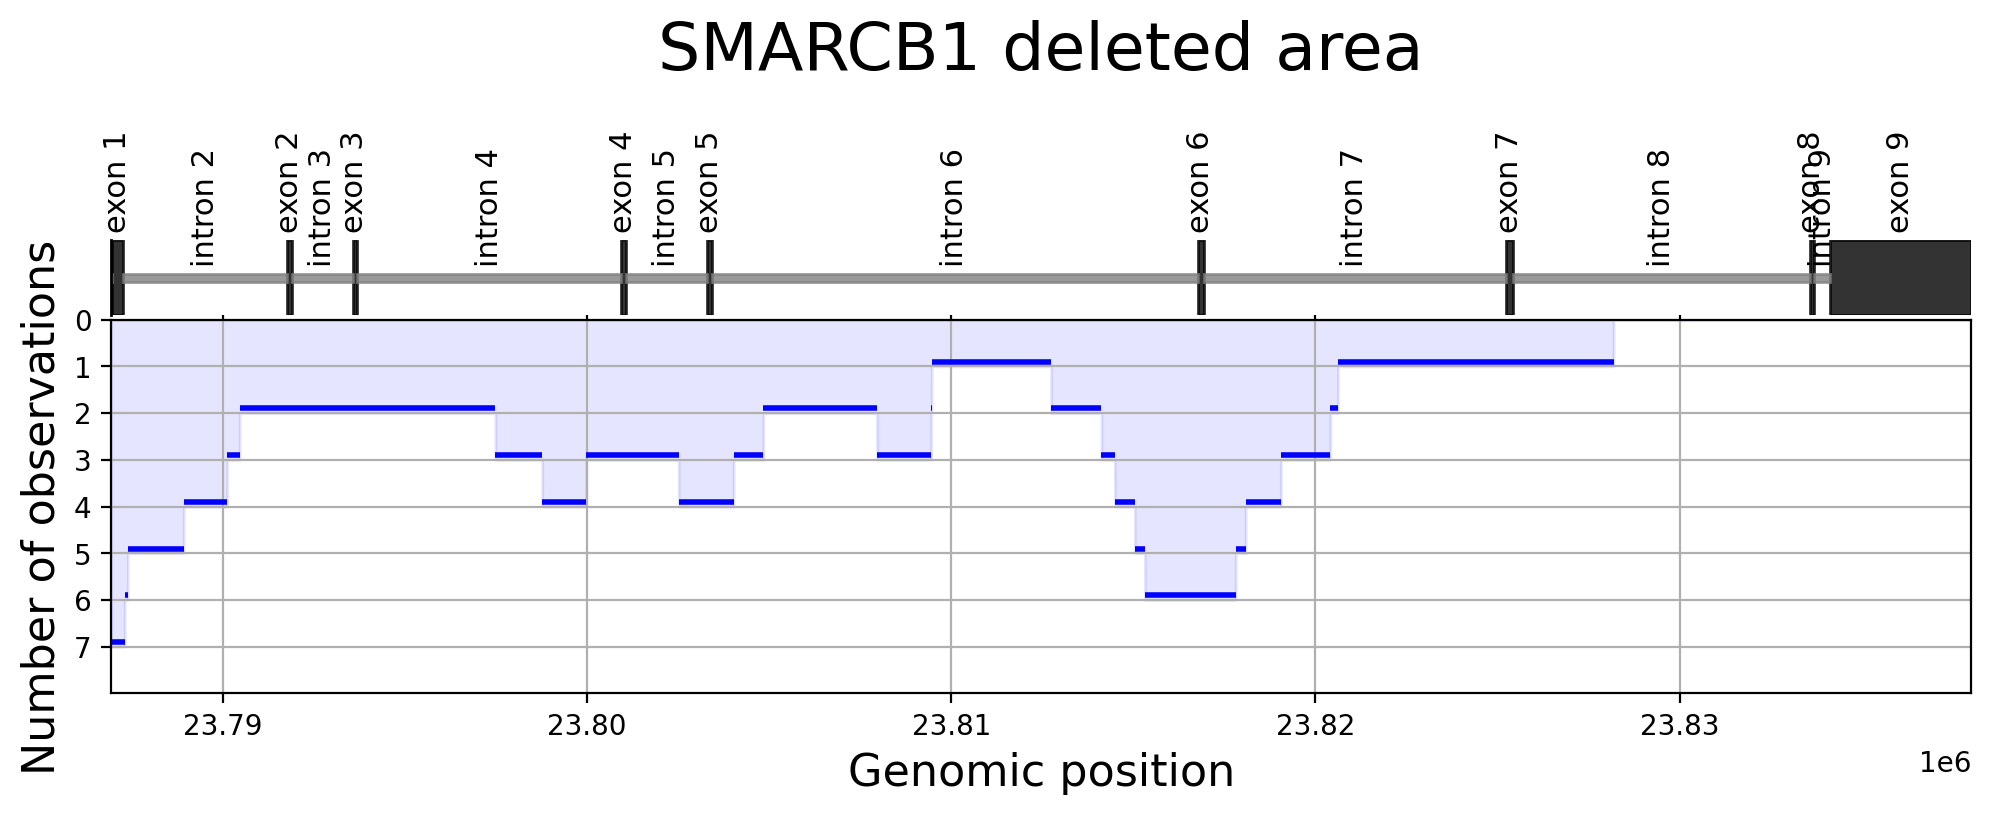

In [42]:
# define figure layout
fig = plt.figure(figsize=(12,3), dpi=200)
# ! SDM change
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 5], width_ratios=[20], hspace=0.02, wspace=0.02)
ax0 = plt.subplot(gs[0, 0])
# ax2 = plt.subplot(gs[-1, :2], sharex=ax1)

gene_start = smarcb1_exons_df['Gene start (bp)'].unique()[0]
gene_end = smarcb1_exons_df['Gene end (bp)'].unique()[0]
print(gene_start, gene_end)

ax0.spines['bottom'].set_visible(False)
ax0.spines['left'].set_linewidth(1)
ax0.spines['right'].set_visible(False)
ax0.spines['top'].set_visible(False)

ax0.set_xlim(gene_start, gene_end)
# ax0.set_ylim(0, 2)
ax0.ticklabel_format(axis='x', style='sci', scilimits=(6, 6))
ax0.set_yticks([])

# rect = patches.Rectangle(xy=(gene_start, 0), width=gene_end, height=5, color='lightgrey', alpha=0.5, zorder=2)
# ax0.add_patch(rect)

start_intron = 0
intron = 1

for i, r in smarcb1_exons_df.iterrows():
	start_exon = r['Exon region start (bp)']
	end_exon = r['Exon region end (bp)']
	size_exon = end_exon - start_exon
	size_intron = start_exon - start_intron
	rect = patches.Rectangle(xy=(start_exon, 0), width=size_exon, height=1, color='k', alpha=0.8, zorder=2)
	
	ax0.text(s='exon '+str(r["Exon rank in transcript"]), x=(start_exon+size_exon/2), y=1.1, fontsize=11, ha='center', va='bottom',rotation=90)
	if start_intron != 0:
		ax0.text(s='intron '+str(intron), x=(start_intron+size_intron/2), y=0.65, fontsize=11, ha='center', va='bottom', rotation=90)
	ax0.add_patch(rect)
	rect = patches.Rectangle(xy=(start_intron, 0.45), width=size_intron, height=0.1, color='grey', alpha=0.8, zorder=2)
	ax0.add_patch(rect)
	start_intron = end_exon
	intron = intron + 1
 
ax1 = plt.subplot(gs[1, 0],sharex=ax0)
xmin = final_merged_table['startpos'].tolist()
xmax = final_merged_table['endpos'].tolist()
y = final_merged_table['total'].tolist()
y = [n+0.1 for n in y]
ax1.hlines(y, xmin, xmax, linewidth=2, color='blue')

# Get x and y data for the plot
xmin = final_merged_table['startpos'].tolist()
xmax = final_merged_table['endpos'].tolist()
y = final_merged_table['total'].tolist()

# Add a colored area under the curve using fill_between
ax1.fill_between(
    x=[val for pair in zip(xmin, xmax) for val in pair], # creates [start1, end1, start2, end2, ...]
    y1=[val for pair in zip(y, y) for val in pair], # repeats each y value to match the x list
    y2=0,
    color='blue',
    alpha=0.1
)

ax1.ticklabel_format(axis='x', style='sci', scilimits=(6,6))
ax1.set_ylim(-8,0)

ax1.set_yticks(ticks=list(range(0,-8,-1)),labels=list(range(0,8,1)))
ax1.set_ylabel('Number of observations',size=16)
ax1.set_xlabel('Genomic position',size=16)
ax1.set_title('SMARCB1 deleted area',size=24,pad=90)
ax1.grid(visible=True)
plt.savefig('plots/exons_del_smarcb1.svg', bbox_inches='tight',format='svg')
plt.show()